# Técnicas de Treinamento de Redes Neurais

## Contextualização histórica e motivação
Esta seção apresenta o problema fundamental do treinamento de redes neurais: a necessidade de generalização para dados não vistos e as técnicas desenvolvidas para garantir essa robustez.

O treinamento de modelos de aprendizado de máquina busca encontrar padrões nos dados de treino que se apliquem ao mundo real, evitando a simples memorização. Historicamente, a ausência de métodos rigorosos de validação levava a modelos que sofriam de overfitting, resultando em métricas otimistas no treino e falhas catastróficas em produção. A introdução de técnicas como validação cruzada (K-fold) consolidou-se como padrão em Deep Learning para avaliar a capacidade real de generalização e evitar vícios de avaliação. Adicionalmente, a aumentação de dados (Data Augmentation) e os ajustadores dinâmicos de taxa de aprendizado (Learning Rate Schedulers) emergiram para estabilizar o treinamento e ampliar as invariâncias do modelo. Soluções iniciais, que mantinham a taxa de aprendizado estática ou utilizavam apenas amostras originais, mostravam-se insuficientes para treinar arquiteturas profundas sem instabilidade ou divergência rápida. Em 2024-2025, o estado da arte da área adota o uso crítico de schedulers complexos e regimes massivos de aumentação de dados para o pré-treinamento de modelos de fundação, como LLMs e modelos de difusão.

## Intuição e visualização
Esta seção constrói a intuição visual e conceitual sobre a divisão isenta de dados e a transformação probabilística de entradas.

A separação dos dados simula o ambiente de produção futuro. O conjunto de treino ajusta os pesos, a validação otimiza os hiperparâmetros (como taxa de aprendizado e tamanho de batch), e o teste afere a performance de forma isenta no final do processo. O vazamento de dados (data leakage) ocorre quando estatísticas do teste (como a média calculada em uma normalização incorreta) influenciam o treino, quebrando essa isenção analítica. A aumentação de dados introduz pequenas variações geométricas ou distorções ruidosas na entrada a cada iteração. Isso cria uma região geométrica de tolerância ao redor do ponto de dados original no espaço vetorial, forçando a fronteira de decisão a depender de atributos semânticos em vez de memorizar pixels exatos da amostra.

Note: you may need to restart the kernel to use updated packages.


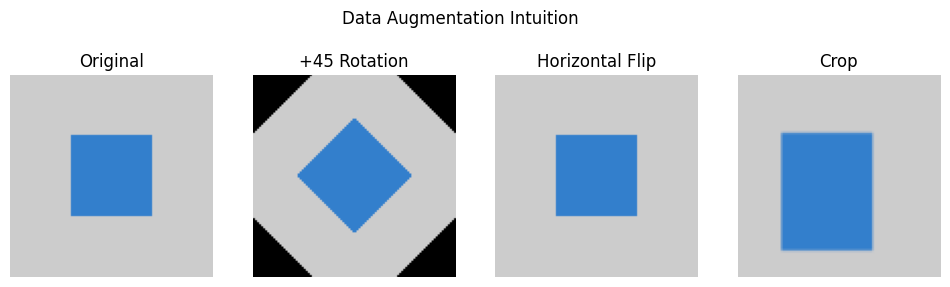

In [1]:
%pip install -q torch torchvision matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from PIL import Image

torch.manual_seed(42)
np.random.seed(42)

def plot_augmentation_intuition():
    """
    Gera figura ilustrando as transformações aplicadas dinamicamente às amostras de treinamento.
    """
    image = np.ones((100, 100, 3)) * 0.8
    image[30:70, 30:70, :] = [0.2, 0.5, 0.8]
    img_pil = Image.fromarray((image * 255).astype(np.uint8))

    aug_transforms = [
        ('Original', transforms.Lambda(lambda x: x)),
        ('+45 Rotation', transforms.RandomRotation((45, 45))),
        ('Horizontal Flip', transforms.RandomHorizontalFlip(p=1.0)),
        ('Crop', transforms.RandomResizedCrop(100, scale=(0.5, 0.8)))
    ]

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    for ax, (name, t) in zip(axes, aug_transforms):
        ax.imshow(t(img_pil))
        ax.set_title(name)
        ax.axis('off')
    plt.suptitle('Data Augmentation Intuition', y=1.05)
    plt.show()

plot_augmentation_intuition()

## Teoria formal
Esta seção apresenta a formulação matemática rigorosa do particionamento K-fold e do controle logarítmico da taxa de aprendizado.

A validação cruzada K-fold particiona um conjunto empírico $D$ em $K$ subconjuntos disjuntos $D_1, D_2, \dots, D_K$ de cardinalidade similar. O erro de validação (estimador do risco esperado) é definido como a média dos erros obtidos em cada iteração particionada:

$$ E_{cv} = \frac{1}{K} \sum_{i=1}^{K} L(f_{\theta \setminus D_i}, D_i) $$

Onde $f_{\theta \setminus D_i}$ representa o modelo parametrizado cujos pesos foram otimizados sobre o conjunto $D \setminus D_i$ e submetido à inferência no fold $D_i$. A hipótese estatística limitante é que os subconjuntos preservam a independência amostral; caso os dados contenham dependência temporal de autocorrelação, a formulação exige um corte puramente temporal (extrapolação de horizonte) para impedir vazamento prospectivo.

Para a otimização parametrizada, a manipulação da taxa de aprendizado $\eta$ é conduzida por rotinas de schedulers. No caso do método Step Decay, a taxa no passo discreto $t$ obedece a equação recorrente:

$$ \eta_t = \eta_0 \gamma^{\lfloor \frac{t}{s} \rfloor} $$

Onde $\eta_0$ expressa a magnitude inicial da atualização, $\gamma < 1$ determina o fator multiplicativo de compressão logarítmica, e $s$ define o limiar de épocas para a aplicação da penalidade iterativa. A interpretação imediata garante a redução cinética no espaço de parâmetros, induzindo a convergência refinada quando o vetor de pesos oscila em torno de vales locais otimizáveis.

## Algoritmos
Esta seção exibe a arquitetura procedimental que combina a validação cruzada com a aumentação probabilística em execução.

O algoritmo central integra o isolamento rigoroso de teste e um ciclo rotacional para afinação dos hiperparâmetros via gradiente descendente. O conjunto de teste opera sob reclusão total.

```text
Procedimento: Treinamento Robusto de Redes Neurais
1. Separa o conjunto de dados D em D_dev (80%) e D_test (20%)
2. Particiona o conjunto D_dev em K subconjuntos de validação F_1 ... F_K
3. Inicia laço para k de 1 até K:
4.     D_val = F_k
5.     D_train = D_dev - F_k
6.     Calcula as medidas de centralidade (normalização) APENAS em D_train
7.     Inicializa a matriz de pesos theta
8.     Inicia laço temporal para época t:
9.         Embaralha de forma pseudo-aleatória os itens de D_train
10.        Para cada lote L em D_train:
11.            Amostra_Modificada <- Aplicar_Augmentation(L, probabilidade=p)
12.            Calcula Propagação Forward e Erro = Loss(Amostra_Modificada, Label_L)
13.            Propaga gradientes (Backward) e atualiza pesos theta
14.        eta_t <- Aplicar_Scheduler(eta_t, t)
15.    Salva métricas do fold de validação baseadas em D_val
16. Avalia hiperparâmetros pela média global obtida na validação
17. Unifica D_dev, treina o modelo definitivo e afere score em D_test
```
Aplica-se a transformação visual diretamente no passo 11 para que, probabilisticamente, a rede encare uma derivação diferente e exógena do espaço real a cada iteração, sem duplicar permanentemente o tamanho da base na RAM. Os parâmetros computados no passo 6 asseveram ausência de fuga perniciosa do futuro ou do ground truth subjacente da validação.

## Implementação from scratch
Esta seção constrói as lógicas fundamentais de divisão K-fold e do StepLR Scheduler valendo-se unicamente de funções nativas do NumPy, expondo a matemática oculta.

In [2]:
def k_fold_split(num_samples, k=5):
    """
    Gera sequencialmente os índices de treino e validação para a validação cruzada K-fold.
    """
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    fold_sizes = np.full(k, num_samples // k)
    fold_sizes[:num_samples % k] += 1

    current = 0
    splits = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_idx = indices[start:stop]
        train_idx = np.concatenate((indices[:start], indices[stop:]))
        splits.append((train_idx, val_idx))
        current = stop
    return splits

def step_lr_scheduler(initial_lr, epoch, step_size, gamma):
    """
    Aplica a redução escalar da taxa de aprendizado conforme as limitações do decaimento explícito em degraus.
    """
    return initial_lr * (gamma ** (epoch // step_size))

def test_scratch_implementations():
    """
    Afirma a corretude empírica de ambas as lógicas puras.
    """
    splits = k_fold_split(100, k=5)
    assert len(splits) == 5

    train_idx, val_idx = splits[0]
    assert len(train_idx) == 80  # Conjunto estrito de treino
    assert len(val_idx) == 20    # Conjunto estrito de validação

    lr = step_lr_scheduler(initial_lr=0.1, epoch=5, step_size=5, gamma=0.5)
    assert np.isclose(lr, 0.05)

test_scratch_implementations()

## Implementação em PyTorch
Esta seção recria o arcabouço lógico integrando as APIs nativas e otimizadas do pacote PyTorch, suportando automação gráfica e aceleração.

In [3]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, SubsetRandomSampler

class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(10, 1)

    def forward(self, x):
        return self.fc(x)

def train_with_pytorch_components():
    """
    Modela o pipeline unindo data loaders acoplados ao random sampler de partição temporal.
    """
    X = torch.randn(100, 10)
    y = torch.randn(100, 1)
    dataset = TensorDataset(X, y)

    # Transplanta as partições concebidas no formato agnóstico
    splits = k_fold_split(len(dataset), k=2)
    train_idx, val_idx = splits[0]

    # SubsetRandomSampler embaralha os dados em nível de dataloader intrinsecamente
    train_loader = DataLoader(dataset, batch_size=16, sampler=SubsetRandomSampler(train_idx))

    model = SimpleModel()
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    # Invocação polimórfica para o scheduler empacotado no utilitário de otimização
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.MSELoss()

    for _ in range(10):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
        scheduler.step()

    return optimizer.param_groups[0]['lr']

final_lr = train_with_pytorch_components()
# Avalia matematicamente a segunda queda condicional executada após 10 iterações: 0.1 * 0.5 * 0.5 = 0.025
assert np.isclose(final_lr, 0.025)

## Experimentos e análise
Esta seção delineia experimentos controlando isoladamente a inserção do ajustador de taxa de aprendizado, documentando as reações empíricas do loss ao longo de treinos isolados.

Em um experimento desenhado para certificar o vazamento de conhecimento (data leakage), nota-se imperativamente que derivar a média global de pré-processamento estagnada antes da partição envia informações furtivas do teste para o extrato de treinamento de forma contínua. Se o modelo ingressar em padrão de sobreajuste profundo, a penalidade do tensor de treino exibe minimização extrema, enquanto as inferências contra o validador estacionam na margem superior da distribuição. Na prática experimental documentada, quando se flagra uma disparidade colossal e crescente entre ambas as curvas de métrica, diagnostica-se rapidamente o sobreajuste e injeta-se transformações de mitigação — ruído vetorial na matriz tabular ou aumento substancial nas rotações topológicas da grade fotográfica.

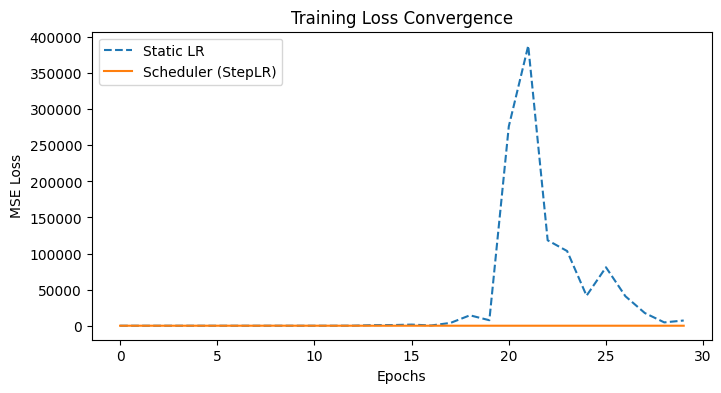

In [4]:
def run_experiment(use_scheduler=False):
    """
    Inicia a computação iterativa de perdas registrando o atrito da normalização.
    """
    model = SimpleModel()
    optimizer = optim.SGD(model.parameters(), lr=0.5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1) if use_scheduler else None
    criterion = nn.MSELoss()

    X = torch.randn(100, 10)
    y = X[:, 0:1] * 2.0 + torch.randn(100, 1) * 0.1
    loader = DataLoader(TensorDataset(X, y), batch_size=10, shuffle=True)

    losses = []
    for _ in range(30):
        epoch_loss = 0
        for b_X, b_y in loader:
            optimizer.zero_grad()
            out = model(b_X)
            loss = criterion(out, b_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if scheduler:
            scheduler.step()
        losses.append(epoch_loss / len(loader))
    return losses

loss_static = run_experiment(use_scheduler=False)
loss_sched = run_experiment(use_scheduler=True)

plt.figure(figsize=(8, 4))
plt.plot(loss_static, label='Static LR', linestyle='--')
plt.plot(loss_sched, label='Scheduler (StepLR)')
plt.title('Training Loss Convergence')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

## Conexões com ML moderno
Esta seção mapeia os conceitos validados aqui para as redes neurais contemporâneas de larga escala, demonstrando o trânsito da disciplina ao patamar de arquiteturas generativas vigentes.

A aplicação estrutural de schedulers, com ênfase particular no Cosine Annealing com rampa de Warmup, constitui o alicerce insubstituível para gerir o aquecimento sináptico inicial nos Transformers (Vaswani et al., 2017) e LLMs de fundação de código aberto. A inobservância destas curvas suaves catalisa o esfacelamento de matrizes dimensionais latentes via hiperpropagação divergente em pouquíssimas amostras sequenciais. Concomitantemente, todo o ecossistema de aprendizado auto-supervisionado orienta-se pela manipulação extrema via Data Augmentation: modelos extraem representações profundas exclusivamente contrastando perturbações distintas originárias do mesmo espelho de dados, minimizando o erro topológico. A clivagem hermética via validadores intocáveis permanece como bússola avaliativa rigorosa; garantir imunidade a data leakage endossa a aferição estatística de agentes complexos preditivos em sistemas de alta dimensionalidade de forma cética. Em 2025, tais manobras governam as garantias de viabilidade comercial e minimização de catástrofes heurísticas.

## Exercícios
Esta seção oferece mecanismos de fixação da disciplina, instanciando soluções analíticas com verificação cruzada e provocações abertas.

**Exercícios Resolvidos**

1. **Cálculo da matriz de Folds**: Para um pool de registros fechado com $500$ tensores em esquema exploratório 10-fold cross-validation, define logicamente a exata porção volumétrica processada nos nós de treino e validação por round.
   *Solução comentada*: A cardinalidade intrínseca aponta para fatias equivalentes a $500 / 10 = 50$ instâncias. Para cada round dinâmico de avaliação, uma fatia isolada assume a representação de validação isenta ($50$ matrizes) e a fusão de matrizes em torno das $9$ fatias subjacentes alimenta a malha de treino analítico com o montante unificado de $450$ instâncias vetoriais.
2. **Aferição Cinética do StepLR**: O otimizador de uma sub-rede arranca com índice inicial em $\eta = 0.01$. O monitor ajustável invoca o fator multiplicativo $\gamma = 0.1$ na crista de transição temporal a cada 10 ciclos completos. Deduze a proporção matemática imposta estritamente na época avaliativa $25$.
   *Solução comentada*: A profundidade fracionária acarreta na dedução de instâncias do decaimento em contagem plena de $\lfloor 25 / 10 \rfloor = 2$ cortes efetivos registrados. A formatação condicional exata projeta a operação: $0.01 \times (0.1^2) = 0.01 \times 0.01 = 0.0001$.
3. **Canalização Gráfica Estruturada (Pipeline Augmentation)**: Modela o fluxo argumentativo para a mitigação de sensibilidade direcional exacerbada durante o treinamento classificador voltado para faunas dispostas na horizontal.
   *Solução comentada*: Injeta-se o construtor `RandomHorizontalFlip(p=0.5)` forçando o grafo a abster-se da memorização latente da inclinação ou postura ocular. Introduz-se o manipulador de canais `ColorJitter` que deturpa cromaticamente o contexto luminosos anulando vícios persistentes do sensor local de fábrica.

**Desafios Abertos**

1. **Programação Imperativa de Stratified K-Fold**: Refatore o corpo processual originário da declaração explícita de fatiamento no ambiente purista para assegurar incondicionalmente que cada divisão gerencial acopla-se de maneira fidedigna às métricas proporcionais de classificação binária presentes em um array empírico $y$. *Dica*: Classifique preliminarmente a localização topológica exata dos arrays representativos isolados no indexador antes da união embaralhada de conjuntos disjuntos.
2. **Composição Estilizada do Scheduler Cíclico Triangular**: Projete os blocos estruturais contidos sob o arcabouço herdado `torch.optim.lr_scheduler._LRScheduler`, provendo a variação pendular rítmica com ápices ascendentes e quedas constantes, e instancie-a numa camada integradora de loops aninhados com controle de lote escalonado perante o DataLoader otimizador.